# EN3160: Image Processing and Machine Vision
## Assignment 1: Intensity Transformations and Neighborhood Filtering

**Department of Electronic and Telecommunication Engineering, University of Moratuwa**

* **Name:** M.R.A.Hakam
* **Index Number:** 230224V
* **GitHub Repository:** [https://github.com/hakammra/EN3160-Assignment-01](https://github.com/hakammra/EN3160-Assignment-01)

In [30]:
from pathlib import Path
import os
import tempfile

os.environ['MPLCONFIGDIR'] = str(Path(tempfile.gettempdir()) / 'en3160-matplotlib')
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_dir = Path('Images/assignment')
if not img_dir.exists():
    img_dir = Path('../Images/assignment')
assert img_dir.exists(), 'Images/assignment folder was not found'

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'

## 1. Piecewise linear intensity transformation

I made the transformation as a 256-value lookup table and applied it using the lecture notation $g=t[f]$. Repeated input coordinates are allowed because the graph in Fig. 1a has two jumps.

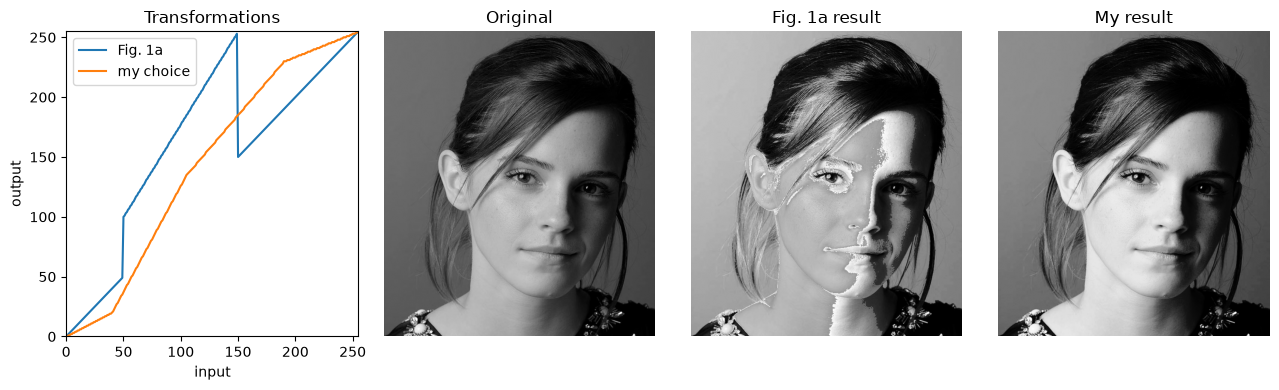

In [31]:
def intensity_transform(im, breakpoints):
    bp = np.asarray(breakpoints, dtype=int)
    if bp.shape[1] != 2 or bp[0, 0] != 0 or bp[-1, 0] != 255:
        raise ValueError('breakpoints must run from input 0 to 255')

    t = np.zeros(256, dtype=float)
    for (r0, s0), (r1, s1) in zip(bp[:-1], bp[1:]):
        if r1 < r0:
            raise ValueError('input values must be in order')
        if r1 == r0:
            t[r0] = s1
        else:
            t[r0:r1 + 1] = np.linspace(s0, s1, r1 - r0 + 1)

    t = np.clip(t, 0, 255).astype(np.uint8)
    return t[im], t

im1 = cv.imread(str(img_dir / 'q1_emma.jpeg'), cv.IMREAD_GRAYSCALE)
bp_given = [[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]]
bp_mine = [[0, 0], [40, 20], [105, 135], [190, 230], [255, 255]]

g1, t1 = intensity_transform(im1, bp_given)
g2, t2 = intensity_transform(im1, bp_mine)

fig, ax = plt.subplots(1, 4, figsize=(13, 4))
ax[0].plot(t1, label='Fig. 1a')
ax[0].plot(t2, label='my choice')
ax[0].set(xlim=(0, 255), ylim=(0, 255), xlabel='input', ylabel='output', title='Transformations')
ax[0].legend()
for a, im, title in zip(ax[1:], [im1, g1, g2], ['Original', 'Fig. 1a result', 'My result']):
    a.imshow(im, vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

The first curve gives the same sudden changes seen in the question. My second curve is gentler: it lifts the midtones while keeping the brightest parts below clipping, so the face looks more natural.

## 2. White-matter and gray-matter accentuation

I inspected the grayscale values and used two intensity windows. The lower window emphasizes the darker white matter, while the higher window emphasizes the brighter gray matter in this PD image.

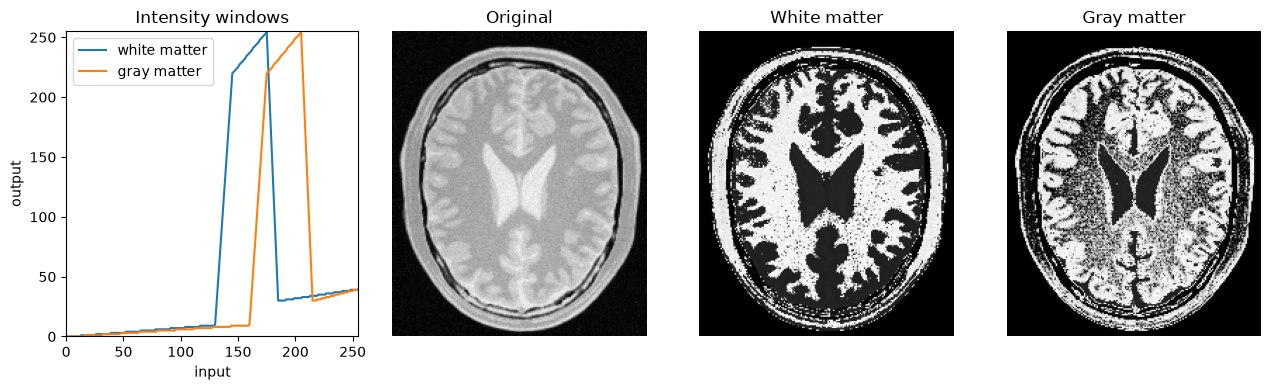

In [32]:
im2 = cv.imread(str(img_dir / 'q2_brain.png'), cv.IMREAD_GRAYSCALE)

bp_wm = [[0, 0], [130, 10], [145, 220], [175, 255], [185, 30], [255, 40]]
bp_gm = [[0, 0], [160, 10], [175, 220], [205, 255], [215, 30], [255, 40]]
wm, t_wm = intensity_transform(im2, bp_wm)
gm, t_gm = intensity_transform(im2, bp_gm)

fig, ax = plt.subplots(1, 4, figsize=(13, 4))
ax[0].plot(t_wm, label='white matter')
ax[0].plot(t_gm, label='gray matter')
ax[0].set(xlim=(0, 255), ylim=(0, 255), xlabel='input', ylabel='output', title='Intensity windows')
ax[0].legend()
for a, im, title in zip(ax[1:], [im2, wm, gm], ['Original', 'White matter', 'Gray matter']):
    a.imshow(im, vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

The two results are not binary segmentations. They are intensity-sliced views: the selected range becomes bright and the other values are suppressed. The gray-matter setting brings out more of the outer folded band, while the white-matter setting favors the darker inner regions.

## 3. Gamma correction in $L^*a^*b^*$

Only the $L$ plane is changed, so the correction mainly affects lightness. I chose $\gamma=0.65$ after trying a few values below 1.

gamma = 0.65
mean L: 71.26 -> 98.60


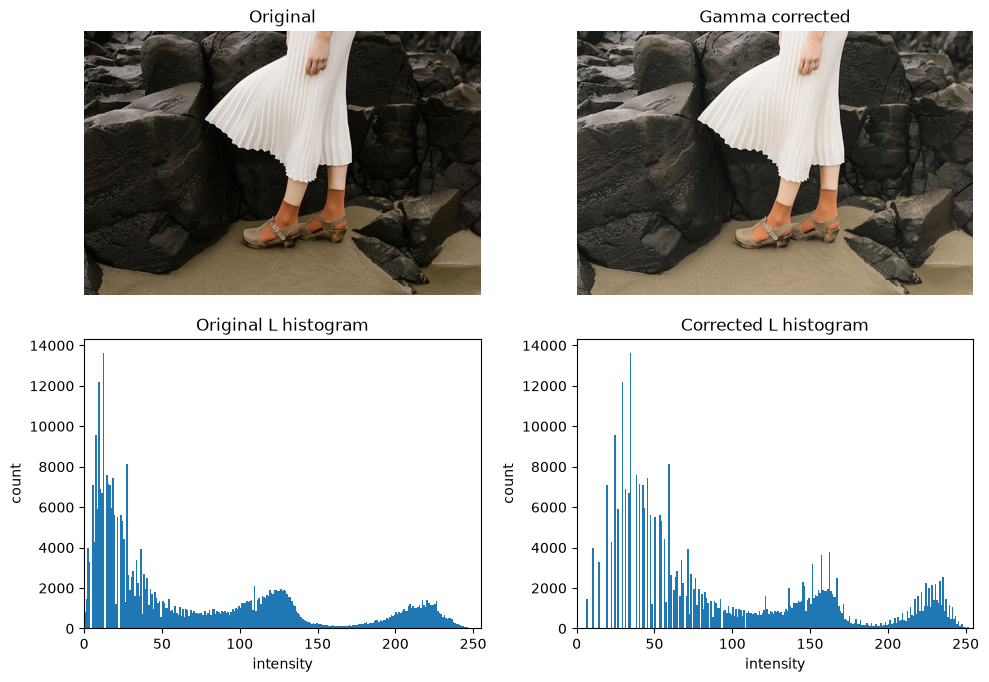

In [33]:
im3_bgr = cv.imread(str(img_dir / 'q3_gamma.jpeg'))
lab = cv.cvtColor(im3_bgr, cv.COLOR_BGR2LAB)
L, a_plane, b_plane = cv.split(lab)

gamma = 0.65
t_gamma = np.array([(i / 255.0) ** gamma * 255 for i in range(256)], dtype=np.uint8)
L2 = t_gamma[L]
out3 = cv.cvtColor(cv.merge([L2, a_plane, b_plane]), cv.COLOR_LAB2RGB)
im3 = cv.cvtColor(im3_bgr, cv.COLOR_BGR2RGB)

print(f'gamma = {gamma}')
print(f'mean L: {L.mean():.2f} -> {L2.mean():.2f}')

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].imshow(im3); ax[0, 0].set_title('Original'); ax[0, 0].axis('off')
ax[0, 1].imshow(out3); ax[0, 1].set_title('Gamma corrected'); ax[0, 1].axis('off')
ax[1, 0].hist(L.ravel(), bins=256, range=(0, 256)); ax[1, 0].set_title('Original L histogram')
ax[1, 1].hist(L2.ravel(), bins=256, range=(0, 256)); ax[1, 1].set_title('Corrected L histogram')
for a in ax[1]:
    a.set(xlim=(0, 255), xlabel='intensity', ylabel='count')
plt.tight_layout()
plt.show()

The corrected histogram moves toward the middle and the mean lightness increases. Dark rocks and clothing become easier to see, but the highlights still retain detail.

## 4. Vibrance using the saturation plane

I used the given transformation on the HSV saturation plane with $\sigma=70$. A value of $a=0.7$ looked strong without making the red suit look flat.

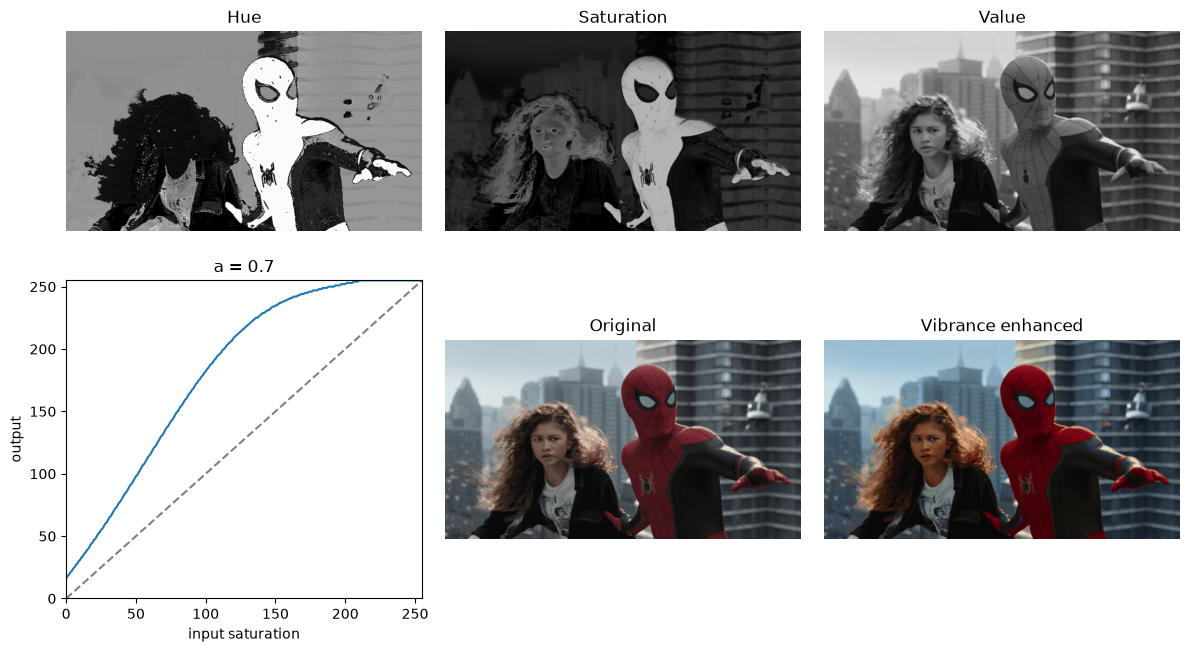

In [34]:
im4_bgr = cv.imread(str(img_dir / 'q4_vibrance.png'))
h4, s4, v4 = cv.split(cv.cvtColor(im4_bgr, cv.COLOR_BGR2HSV))

a_value = 0.7
sigma = 70.0
x = np.arange(256, dtype=float)
t_vib = np.clip(x + a_value * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 0, 255).astype(np.uint8)
s4_new = t_vib[s4]
out4 = cv.cvtColor(cv.merge([h4, s4_new, v4]), cv.COLOR_HSV2RGB)
im4 = cv.cvtColor(im4_bgr, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for a, im, title, vmax in zip(ax[0], [h4, s4, v4], ['Hue', 'Saturation', 'Value'], [179, 255, 255]):
    a.imshow(im, vmin=0, vmax=vmax)
    a.set_title(title); a.axis('off')
ax[1, 0].plot(t_vib); ax[1, 0].plot([0, 255], [0, 255], '--', color='gray')
ax[1, 0].set(xlim=(0, 255), ylim=(0, 255), xlabel='input saturation', ylabel='output', title=f'a = {a_value}')
ax[1, 1].imshow(im4); ax[1, 1].set_title('Original'); ax[1, 1].axis('off')
ax[1, 2].imshow(out4); ax[1, 2].set_title('Vibrance enhanced'); ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

The added saturation is largest around the middle of the range and smaller near the ends. The muted background and clothing gain color, while already saturated areas reach 255 and are clipped by the formula.

## 5. Histogram equalization

This uses the discrete CDF expression from the point-operations lecture: $t_k=(L-1)\,CDF(k)/(MN)$, followed by $g=t[f]$.

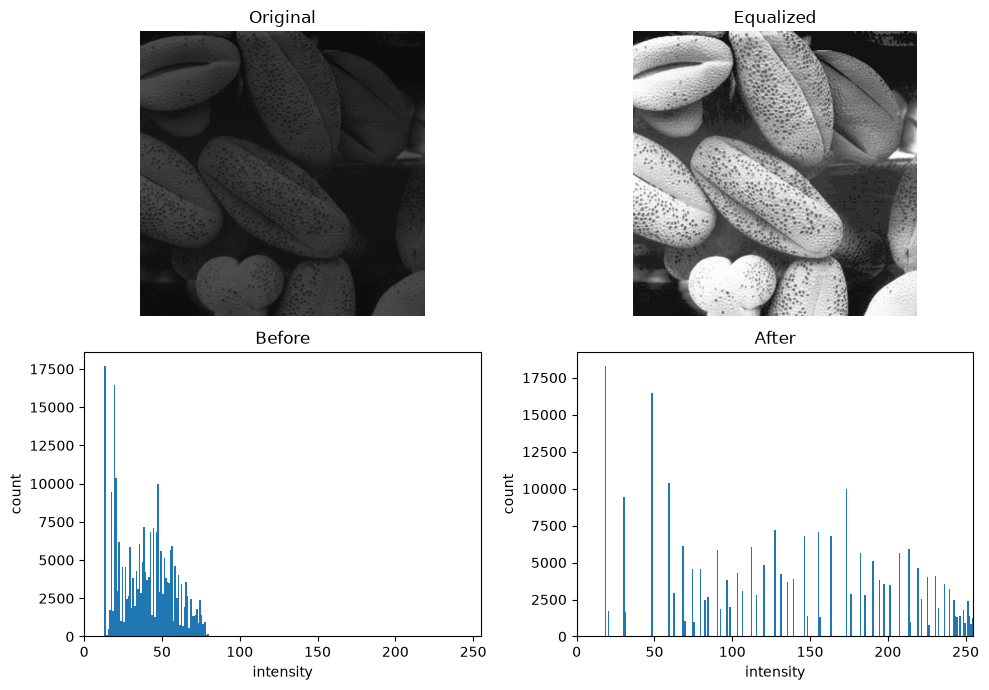

In [35]:
def my_hist_equalize(im):
    M, N = im.shape
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    t = (255 * cdf / (M * N)).astype(np.uint8)
    return t[im], t

im5 = cv.imread(str(img_dir / 'q5_beans.png'), cv.IMREAD_GRAYSCALE)
out5, t5 = my_hist_equalize(im5)

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].imshow(im5, vmin=0, vmax=255); ax[0, 0].set_title('Original'); ax[0, 0].axis('off')
ax[0, 1].imshow(out5, vmin=0, vmax=255); ax[0, 1].set_title('Equalized'); ax[0, 1].axis('off')
ax[1, 0].hist(im5.ravel(), bins=256, range=(0, 256)); ax[1, 0].set_title('Before')
ax[1, 1].hist(out5.ravel(), bins=256, range=(0, 256)); ax[1, 1].set_title('After')
for a in ax[1]:
    a.set(xlim=(0, 255), xlabel='intensity', ylabel='count')
plt.tight_layout()
plt.show()

The original values are crowded into the dark part of the histogram. Equalization spreads them over a much wider range and makes the texture on the beans visible. The output histogram is not perfectly flat because the image and intensity levels are discrete.

## 6. Histogram equalization of the foreground

The saturation plane separates the colored subject from the gray background better than the value plane. I used Otsu thresholding, kept the largest connected area, and filled its internal holes before equalizing only its $V$ values.

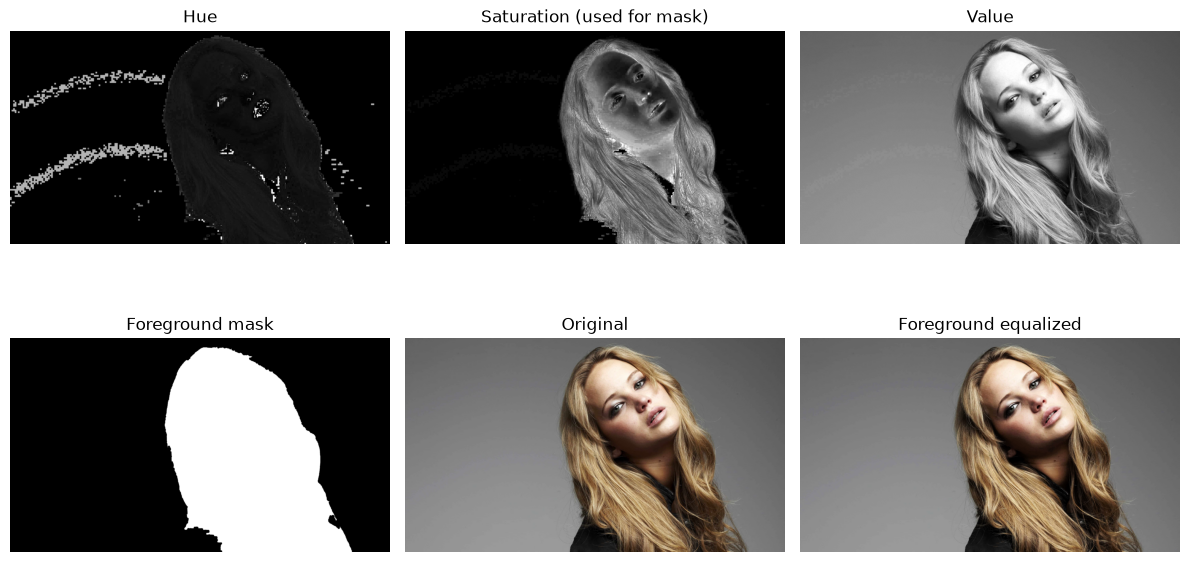

In [36]:
im6_bgr = cv.imread(str(img_dir / 'q6_girl.jpeg'))
h6, s6, v6 = cv.split(cv.cvtColor(im6_bgr, cv.COLOR_BGR2HSV))

_, mask6 = cv.threshold(s6, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (21, 21))
mask6 = cv.morphologyEx(mask6, cv.MORPH_CLOSE, kernel)

n, labels, stats, _ = cv.connectedComponentsWithStats(mask6)
largest = 1 + np.argmax(stats[1:, cv.CC_STAT_AREA])
mask6 = np.where(labels == largest, 255, 0).astype(np.uint8)

flood = mask6.copy()
pad = np.zeros((mask6.shape[0] + 2, mask6.shape[1] + 2), np.uint8)
cv.floodFill(flood, pad, (0, 0), 255)
mask6 = cv.bitwise_or(mask6, cv.bitwise_not(flood))

fg_v = cv.bitwise_and(v6, v6, mask=mask6)
fg_pixels = fg_v[mask6 > 0]
hist_fg = np.bincount(fg_pixels, minlength=256)
cdf_fg = np.cumsum(hist_fg)
t_fg = (255 * cdf_fg / len(fg_pixels)).astype(np.uint8)

eq_fg = np.zeros_like(v6)
eq_fg[mask6 > 0] = t_fg[v6[mask6 > 0]]
bg_v = cv.bitwise_and(v6, v6, mask=cv.bitwise_not(mask6))
v6_new = cv.add(eq_fg, bg_v)
out6 = cv.cvtColor(cv.merge([h6, s6, v6_new]), cv.COLOR_HSV2RGB)
im6 = cv.cvtColor(im6_bgr, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for a, im, title in zip(ax[0], [h6, s6, v6], ['Hue', 'Saturation (used for mask)', 'Value']):
    a.imshow(im); a.set_title(title); a.axis('off')
for a, im, title in zip(ax[1], [mask6, im6, out6], ['Foreground mask', 'Original', 'Foreground equalized']):
    a.imshow(im); a.set_title(title); a.axis('off')
plt.tight_layout()
plt.show()

The background is unchanged because its original V values are added back. The foreground contrast becomes stronger, especially in the hair. Filling the mask holes avoids leaving patchy, unequalized regions on the face.